In [ ]:
# Blessing Anoroh
# Assginment Data Set week 6
# Dat 620 - Web Analytics
# Date: March 15, 2026 (Due)

Biadjacency matrix
<Compressed Sparse Row sparse array of dtype 'int64'
	with 89 stored elements and shape (18, 14)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 7)	1
  (0, 8)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	1
  (1, 7)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	1
  (2, 4)	1
  (2, 5)	1
  (2, 6)	1
  (2, 7)	1
  (2, 8)	1
  (3, 0)	1
  (3, 2)	1
  :	:
  (12, 7)	1
  (12, 8)	1
  (12, 9)	1
  (12, 11)	1
  (12, 12)	1
  (12, 13)	1
  (13, 5)	1
  (13, 6)	1
  (13, 8)	1
  (13, 9)	1
  (13, 10)	1
  (13, 11)	1
  (13, 12)	1
  (13, 13)	1
  (14, 6)	1
  (14, 7)	1
  (14, 9)	1
  (14, 10)	1
  (14, 11)	1
  (15, 7)	1
  (15, 8)	1
  (16, 8)	1
  (16, 10)	1
  (17, 8)	1
  (17, 10)	1

#Friends, Member
17 Evelyn Jefferson
15 Laura Mandeville
17 Theresa Anderson
15 Brenda Rogers
11 Charlotte McDowd
15 Frances Anderson
15 Eleanor Nye
16 Pearl Oglethorpe
17 Ruth DeSand
17 Verne Sanderson
16 Myra Liddel
16 Katherina Rogers
17 Sylvia Avondale
17 Nora Fayette
1

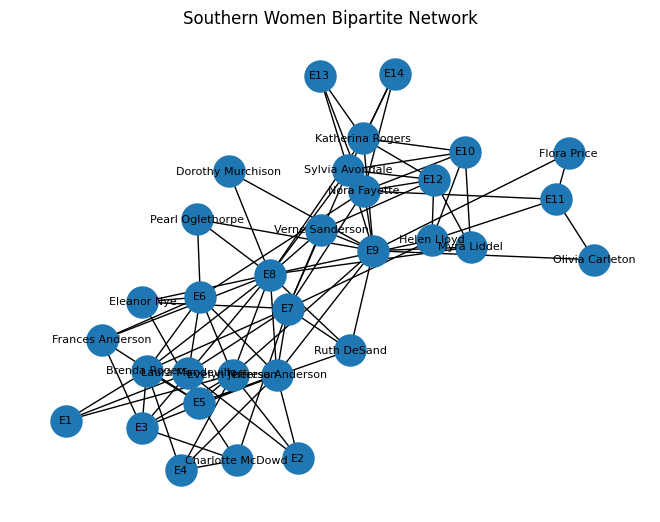

In [1]:
# code from networkx data source for dataset of Davis Club
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite

G = nx.davis_southern_women_graph()
women = G.graph["top"]
clubs = G.graph["bottom"]

print("Biadjacency matrix")
print(bipartite.biadjacency_matrix(G, women, clubs))

# project bipartite graph onto women nodes
W = bipartite.projected_graph(G, women)
print()
print("#Friends, Member")
for w in women:
    print(f"{W.degree(w)} {w}")

# weighted projection
W_weighted = bipartite.weighted_projected_graph(G, women)
print()
print("#Friend meetings, Member")
for w in women:
    print(f"{W_weighted.degree(w, weight='weight')} {w}")

pos = nx.spring_layout(G, seed=648)
nx.draw(G, pos, with_labels=True, node_size=500, font_size=8)
plt.title("Southern Women Bipartite Network")
plt.show()

**My Input for Analysis**

In [2]:
# my Input codes for Analysis


import pandas as pd
from networkx.algorithms.community import greedy_modularity_communities

# separate women and events
events = clubs

# women projection
women_graph = bipartite.weighted_projected_graph(G, women)

# event projection
event_graph = bipartite.weighted_projected_graph(G, events)

# centrality for women
degree_centrality = nx.degree_centrality(women_graph)
betweenness_centrality = nx.betweenness_centrality(women_graph)
eigenvector_centrality = nx.eigenvector_centrality(women_graph, max_iter=1000)

women_df = pd.DataFrame({
    "Woman": list(women),
    "Degree Centrality": [degree_centrality[n] for n in women],
    "Betweenness Centrality": [betweenness_centrality[n] for n in women],
    "Eigenvector Centrality": [eigenvector_centrality[n] for n in women],
    "Events Attended": [G.degree(n) for n in women]
}).sort_values(by="Degree Centrality", ascending=False)

print("\nWomen centrality results:")
print(women_df)

# event attendance
event_df = pd.DataFrame({
    "Event": list(events),
    "Attendance": [G.degree(e) for e in events]
}).sort_values(by="Attendance", ascending=False)

print("\nEvent attendance counts:")
print(event_df)

# communities
communities = greedy_modularity_communities(women_graph)

print("\nCommunities found:", len(communities))
for i, community in enumerate(communities, 1):
    print(f"Community {i}: {sorted(community)}")


Women centrality results:
                Woman  Degree Centrality  Betweenness Centrality  \
0    Evelyn Jefferson           1.000000                0.010122   
2    Theresa Anderson           1.000000                0.010122   
12    Sylvia Avondale           1.000000                0.010122   
9     Verne Sanderson           1.000000                0.010122   
8         Ruth DeSand           1.000000                0.010122   
13       Nora Fayette           1.000000                0.010122   
14        Helen Lloyd           1.000000                0.010122   
10        Myra Liddel           0.941176                0.005348   
11   Katherina Rogers           0.941176                0.005348   
7    Pearl Oglethorpe           0.941176                0.005348   
15  Dorothy Murchison           0.941176                0.005348   
1    Laura Mandeville           0.882353                0.002674   
5    Frances Anderson           0.882353                0.002674   
3       Brenda Rogers

## Assignment Question /Analysis : What can you infer about the relationships between (1) the women, and (2) the social events?

From the network results, we can infer that the relationships between the women are strongly connected through the social events they attend. Many of the women went to the same gatherings, which creates many shared connections between them. The women projection shows a dense network, meaning most of the women are linked to each other through shared event attendance. Some women such as Evelyn Jefferson, Theresa Anderson, Sylvia Avondale, and Nora Fayette appear to be more central in the network because they attended more events and are connected to many others. This suggests that these women likely played an important role in connecting different people in the social group.

The events themselves also play an important role in forming these relationships. Some events had much higher attendance than others, which means they likely served as major social gatherings. For example, Event E8 had the highest attendance, followed by E9 and E7, bringing many women together at the same time. The analysis also shows that the women form two main social groups, but the events help connect these groups because many women attend multiple gatherings. Overall, the social events act as the main way the women interact and build relationships within the network.